In [21]:
import numpy as np
import pandas as pd


In [22]:
from google.colab import files


uploaded = files.upload()


data = pd.read_csv("laptop_price (2).csv", encoding="latin-1")
data.head()


Saving laptop_price (2).csv to laptop_price (2) (1).csv


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [24]:
data.head(2)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94


#  Convert RAM and Weight into numeric




In [25]:
# Convert RAM and Weight into numeric
data['Ram'] = data['Ram'].str.replace('GB','').astype('int32')
data['Weight'] = data['Weight'].str.replace('kg','').astype('float32')

In [26]:
data.head(2)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94


# company column

In [27]:
data['Company'].value_counts()

,count
Company,
Dell,297
Lenovo,297
HP,274
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9


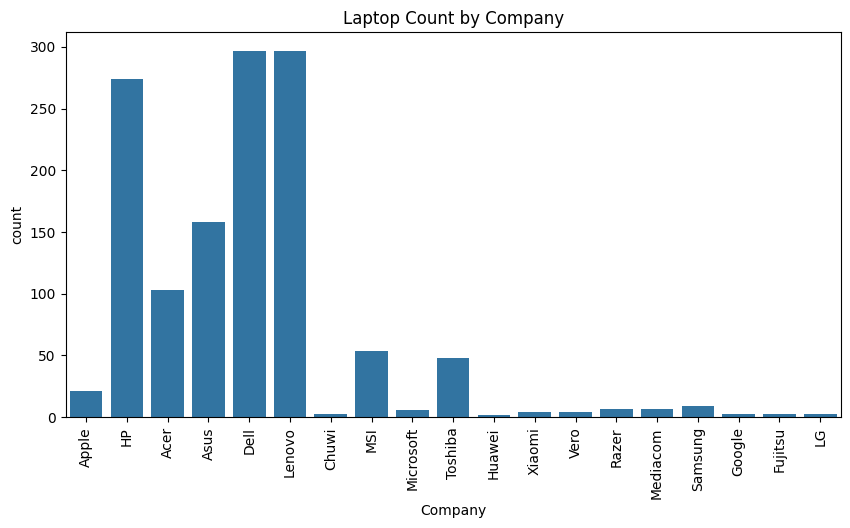

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(x="Company", data=data)
plt.xticks(rotation=90)
plt.title("Laptop Count by Company")
plt.show()

In [29]:
# Combine rare companies into "Other"
def add_company(inpt):
    if inpt in ['Samsung','Razer','Mediacom','Microsoft','Xiaomi','Vero','Chuwi','Google','Fujitsu','LG','Huawei']:
        return 'Other'
    else:
        return inpt
data['Company'] = data['Company'].apply(add_company)


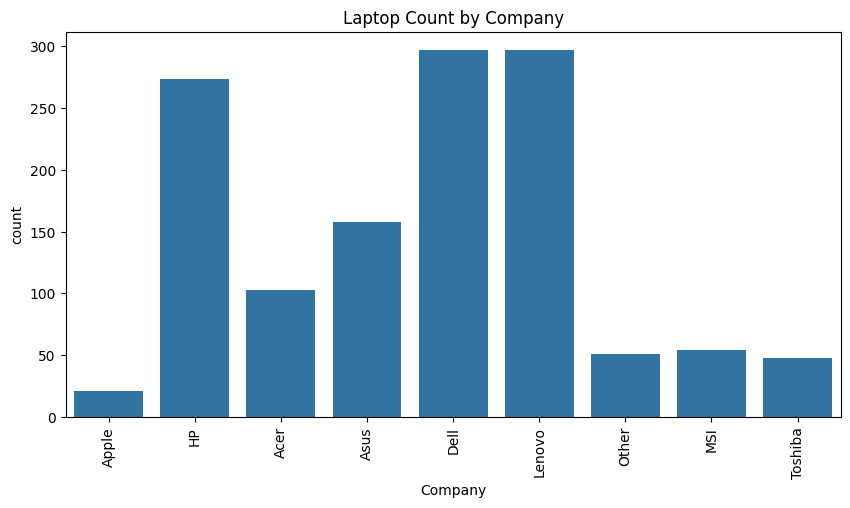

In [30]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(x="Company", data=data)
plt.xticks(rotation=90)
plt.title("Laptop Count by Company")
plt.show()

# Simplify Operating System

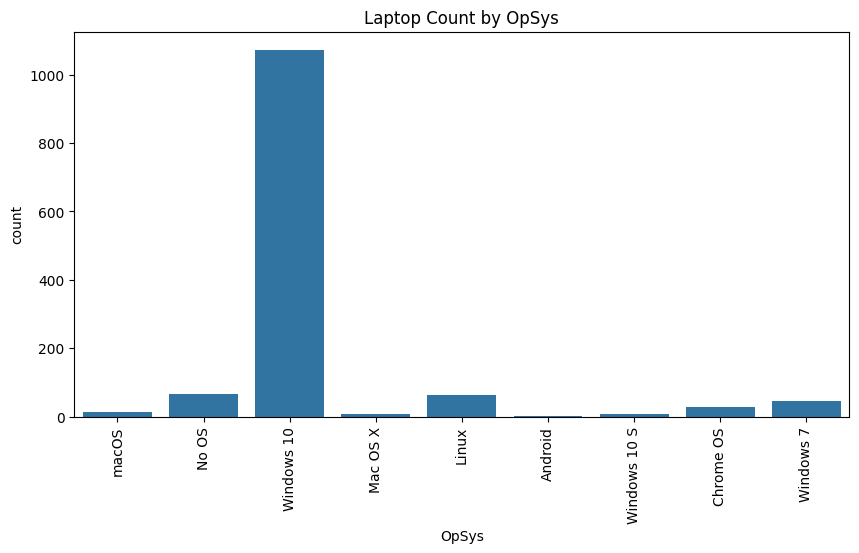

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(x="OpSys", data=data)
plt.xticks(rotation=90)
plt.title("Laptop Count by OpSys")
plt.show()

In [32]:
# Simplify Operating System
def set_os(inpt):
    if inpt in ['Windows 10','Windows 7','Windows 10 S']:
        return 'Windows'
    elif inpt in ['macOS','Mac OS X']:
        return 'Mac'
    elif inpt == 'Linux':
        return 'Linux'
    else:
        return 'Other'
data['OpSys'] = data['OpSys'].apply(set_os)

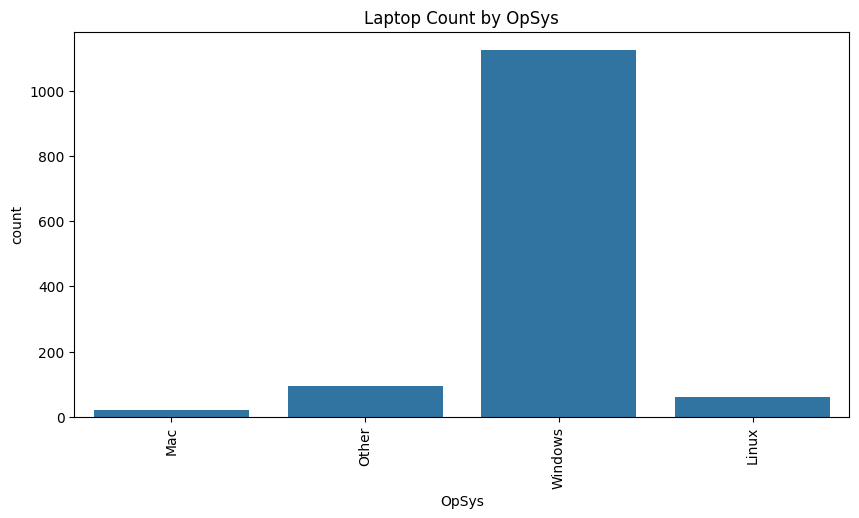

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(x="OpSys", data=data)
plt.xticks(rotation=90)
plt.title("Laptop Count by OpSys")
plt.show()

# One hot encoding

In [34]:
final_data = pd.get_dummies(data ,dtype = int)
display(final_data)

,laptop_ID,Inches,Ram,Weight,Price_euros,Company_Acer,Company_Apple,Company_Asus,Company_Dell,Company_HP,...,Gpu_Nvidia Quadro M2200M,Gpu_Nvidia Quadro M3000M,Gpu_Nvidia Quadro M500M,Gpu_Nvidia Quadro M520M,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Linux,OpSys_Mac,OpSys_Other,OpSys_Windows
0,1,13.3,8,1.37,1339.69,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2,13.3,8,1.34,898.94,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,15.6,8,1.86,575.00,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,4,15.4,16,1.83,2537.45,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,5,13.3,8,1.37,1803.60,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,14.0,4,1.80,638.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1299,1317,13.3,16,1.30,1499.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1300,1318,14.0,2,1.50,229.00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1301,1319,15.6,6,2.19,764.00,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
